<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Adease_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AdEase Time series Business case


Ad Ease is a marketing company that helps businesses get maximum clicks at minimum cost. It offers ad infrastructure to promote businesses easily, effectively, and economically.

The platform uses three AI modules — Design, Dispense, and Decipher. These work together to form a complete, three-step digital advertising solution.

You are part of the Data Science team at Ad Ease. Your goal is to analyze page view reports from Wikipedia over 550 days.

The dataset contains daily view counts for 145,000 Wikipedia pages. You aim to forecast future views to help optimize ad placements.

Your clients come from different regions. They need insights on how their ads will perform on pages in various languages.

In [ ]:
# Importing required packages for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
#from fbprophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error as mape
import warnings
warnings.filterwarnings("ignore")


In [ ]:
Exog_Campaign = pd.read_csv("/content/Exog_Campaign_eng.csv")
print(Exog_Campaign.head())

   Exog
0     0
1     0
2     0
3     0
4     0


In [ ]:
print(Exog_Campaign.describe())
print(Exog_Campaign.info())

             Exog
count  550.000000
mean     0.098182
std      0.297831
min      0.000000
25%      0.000000
50%      0.000000
75%      0.000000
max      1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exog    550 non-null    int64
dtypes: int64(1)
memory usage: 4.4 KB
None


In [ ]:
# Load dataset
df = pd.read_csv('/content/train_1.csv')  # Replace with your file path

# Check structure
print(df.shape)
print(df.info())
print(df.head())

(145063, 551)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB
None
                                                Page  2015-07-01  2015-07-02  \
0            2NE1_zh.wikipedia.org_all-access_spider        18.0        11.0   
1             2PM_zh.wikipedia.org_all-access_spider        11.0        14.0   
2              3C_zh.wikipedia.org_all-access_spider         1.0         0.0   
3         4minute_zh.wikipedia.org_all-access_spider        35.0        13.0   
4  52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...         NaN         NaN   

   2015-07-03  2015-07-04  2015-07-05  2015-07-06  2015-07-07  2015-07-08  \
0         5.0        13.0        14.0         9.0         9.0        22.0   
1        15.0        18.0        11.0        13.0        22.0        11.0   
2         1.0         1.0         0.0         4.0         0.0         3.0   
3        10.0    

Data Dictionary:

There are two csv files given

train_1.csv: In the csv file, each row corresponds to a particular article and each column corresponds to a particular date. The values are the number of visits on that date.

The page name contains data in this format:

SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN

having information about the page name, the main domain, the device type used to access the page, and also the request origin(spider or browser agent)

Exog_Campaign_eng: This file contains data for the dates which had a campaign or significant event that could affect the views for that day. The data is just for pages in English.

There’s 1 for dates with campaigns and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in English

0      117277
1         962
125       773
550       652
2         613
        ...  
408        13
422        12
530        12
296        12
488        12
Name: count, Length: 551, dtype: int64


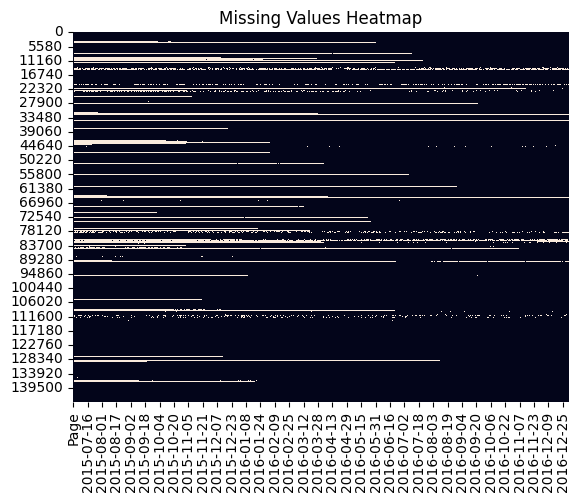

In [ ]:
# Check missing values
missing = df.isnull().sum(axis=1)
print(missing.value_counts())

# Visualize missing data
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [ ]:
# Drop all the rows where views for all dates are missing
df = df[~((df.isna().sum(axis=1) == 550))].copy()
df.shape

(144411, 551)

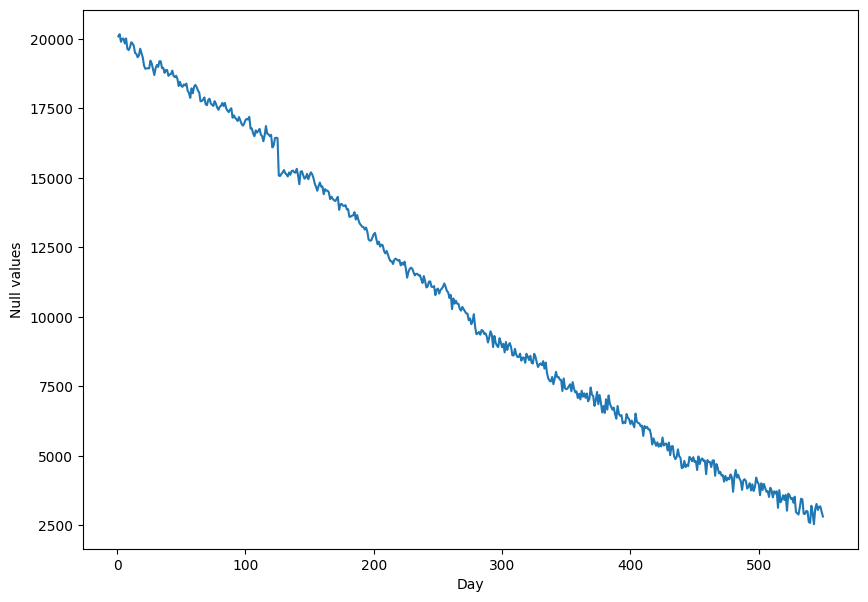

In [ ]:

days = [r for r in range(1, len(df.columns))]

plt.figure(figsize=(10,7))
plt.xlabel('Day')
plt.ylabel('Null values')
plt.plot(days, df.isnull().sum()[1:])


Data Cleaning Insight:

From the plot, we can clearly see that the number of null values decreases over time. This suggests that many Wikipedia pages didn’t exist initially—so it's expected they had no recorded views during those earlier days.

As part of data cleaning, we first remove rows where all values are null—these pages likely have no useful information.
Next, we drop rows with more than 300 null values. Since we have a total of 551 records, keeping rows with over 300 missing values means more than half the data is missing for those pages. Such incomplete data would negatively impact model performance, so it's better to exclude them from the analysis.

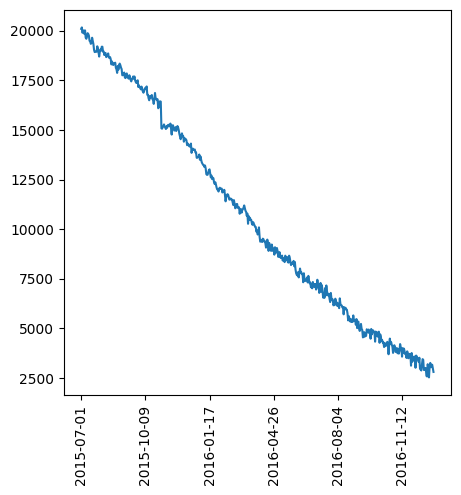

In [ ]:
# Null values for different dates
plt.figure(figsize=(5,5))
df.iloc[:,1:].isna().sum(axis=0).plot()
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Get the date range of columns
start_date, end_date = df.columns[1:].min(), df.columns[1:].max()
print(f"Columns date range: {start_date} till {end_date}")

Columns date range: 2015-07-01 till 2016-12-31


In [ ]:
## Drop duplicates if available
df = df.drop_duplicates()
df.shape

(144411, 551)

Insights:
There are no duplicates in the dataset
0.45% (652) pages have all values as Null. Therefore dropped those pages

In [ ]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [ ]:
df=df.dropna(thresh=300)
print(df.shape)

(133617, 551)


In [ ]:
df=df.fillna(0)


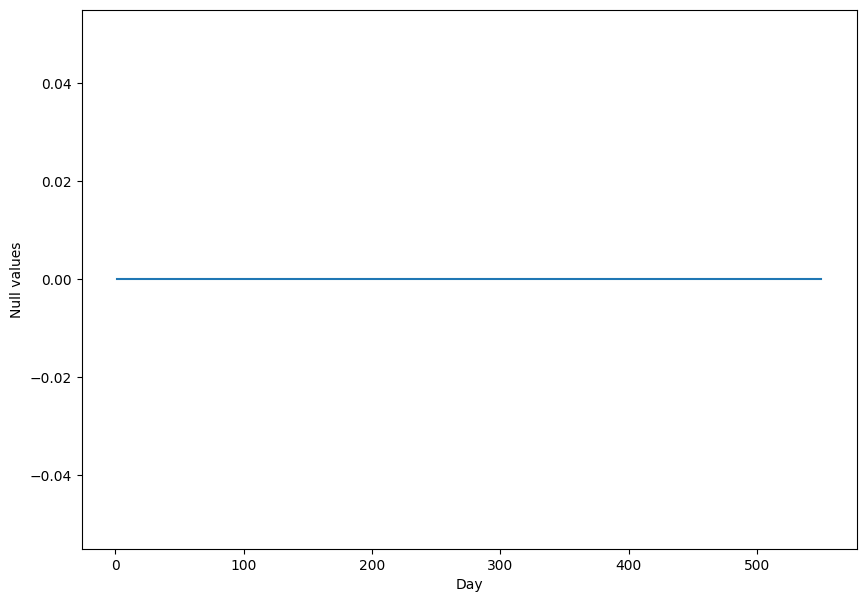

In [ ]:
days = [r for r in range(1, len(df.columns))]
plt.figure(figsize=(10,7))
plt.xlabel('Day')
plt.ylabel('Null values')
plt.plot(days, df.isnull().sum()[1:])

In [ ]:
# Split 'Page' into components
split_df = df['Page'].str.extract(r'^(.*?)_([a-z]{2})\.wikipedia\.org_([^_]+)_([^_]+)$')
split_df.columns = ['Title', 'Language', 'Access_Type', 'Access_Origin']
df = pd.concat([split_df, df.drop('Page', axis=1)], axis=1)


In [ ]:
df.head()

,Title,Language,Access_Type,Access_Origin,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1,zh,all-access,spider,18.0,11.0,5.0,13.0,14.0,9.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM,zh,all-access,spider,11.0,14.0,15.0,18.0,11.0,13.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C,zh,all-access,spider,1.0,0.0,1.0,1.0,0.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute,zh,all-access,spider,35.0,13.0,10.0,94.0,4.0,26.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
5,5566,zh,all-access,spider,12.0,7.0,4.0,5.0,20.0,8.0,...,16.0,27.0,8.0,17.0,32.0,19.0,23.0,17.0,17.0,50.0


<Axes: xlabel='count', ylabel='Language'>

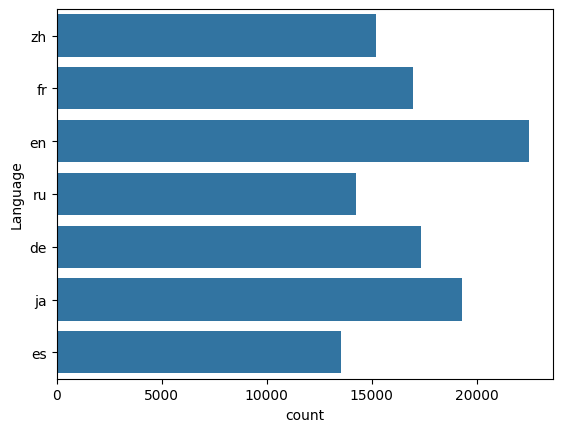

In [ ]:
sns.countplot(df["Language"])


<Axes: xlabel='count', ylabel='Access_Type'>

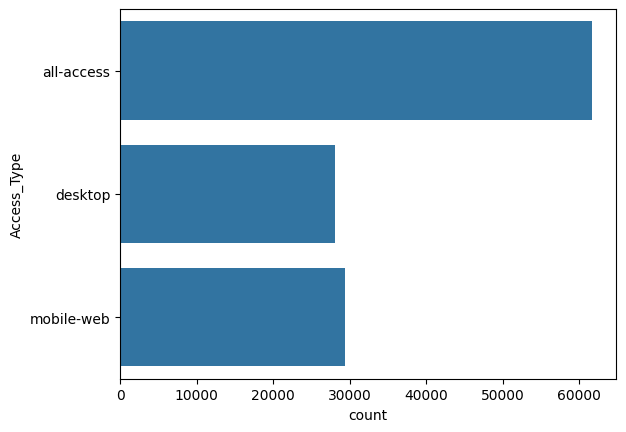

In [ ]:
sns.countplot(df["Access_Type"])

<Axes: xlabel='count', ylabel='Access_Origin'>

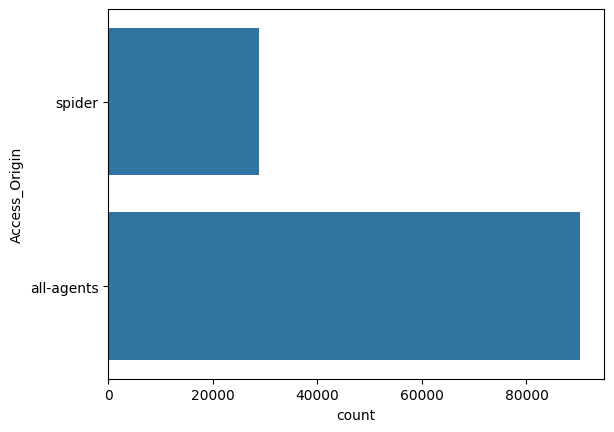

In [ ]:
sns.countplot(df["Access_Origin"])


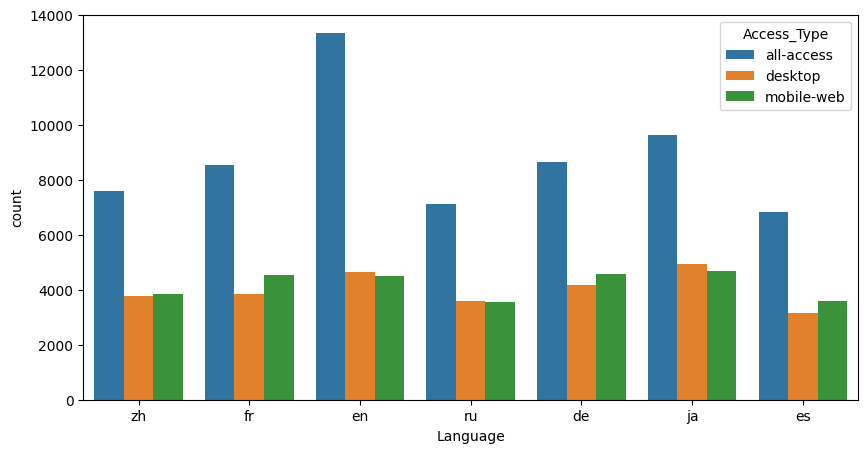

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Language",hue="Access_Type");

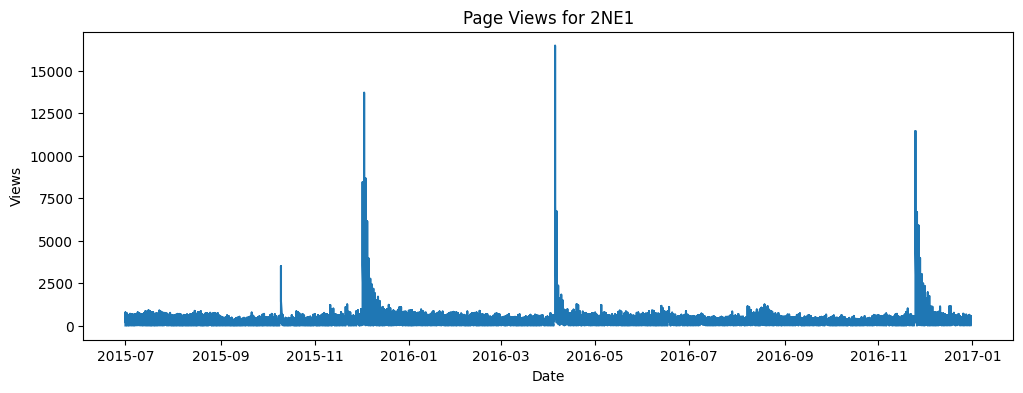

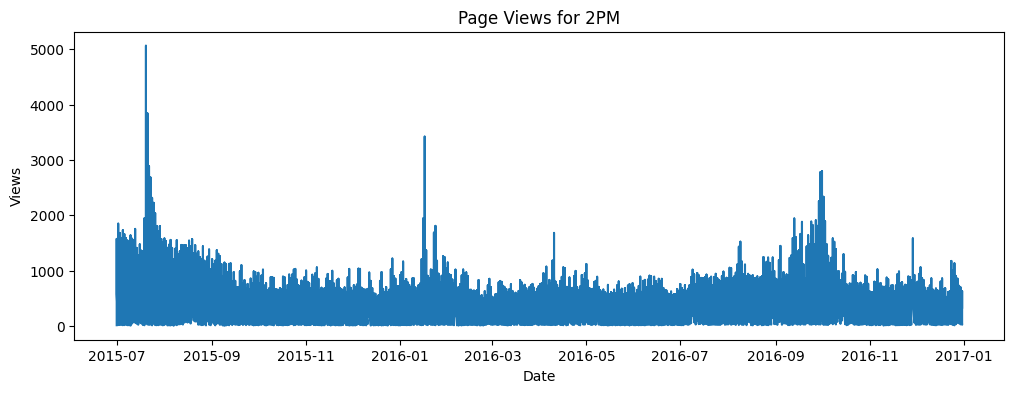

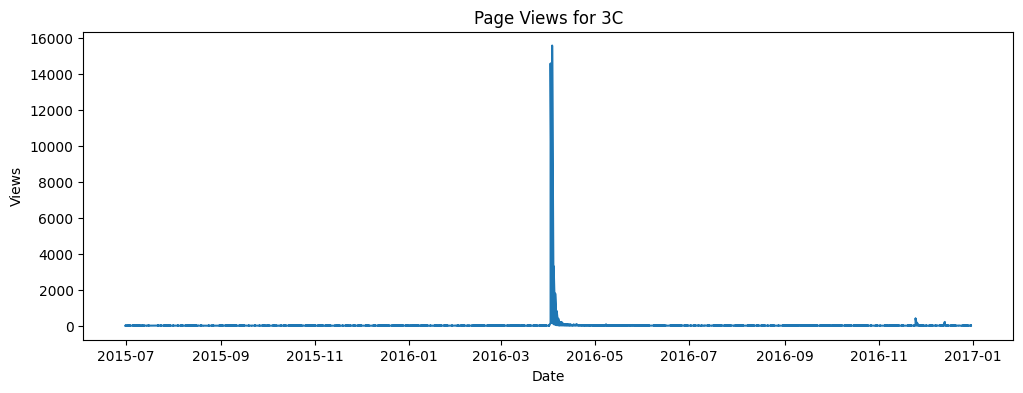

In [ ]:
# Melt to long format for time series
df_melted = df.melt(id_vars=['Title', 'Language', 'Access_Type', 'Access_Origin'], var_name='Date', value_name='Views')
df_melted['Date'] = pd.to_datetime(df_melted['Date'])

# Visualize a few titles
titles = df['Title'].unique()[:3]
for title in titles:
    subset = df_melted[df_melted['Title'] == title]
    plt.figure(figsize=(12, 4))
    plt.plot(subset['Date'], subset['Views'])
    plt.title(f"Page Views for {title}")
    plt.xlabel("Date")
    plt.ylabel("Views")
    plt.show()


In [ ]:
df.head()

,Title,Language,Access_Type,Access_Origin,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1,zh,all-access,spider,18.0,11.0,5.0,13.0,14.0,9.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM,zh,all-access,spider,11.0,14.0,15.0,18.0,11.0,13.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C,zh,all-access,spider,1.0,0.0,1.0,1.0,0.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute,zh,all-access,spider,35.0,13.0,10.0,94.0,4.0,26.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
5,5566,zh,all-access,spider,12.0,7.0,4.0,5.0,20.0,8.0,...,16.0,27.0,8.0,17.0,32.0,19.0,23.0,17.0,17.0,50.0


In [ ]:
# Remove known non-numeric columns first
df_clean = df.drop(columns=["Title",'Access_Type','Access_Origin'])

# Now ensure every remaining column is numeric (or NaN)
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# Join back 'Language' column for grouping
df_clean["Language"] = df["Language"]



In [ ]:
# Group by Language on numeric data only
df_lang = df_clean.groupby("Language").mean().transpose()

# Preview
df_lang.head(10)


Language,de,en,es,fr,ja,ru,zh
2015-07-01,763.765926,3767.328604,1127.485204,499.092872,614.637160,663.199229,272.498521
2015-07-02,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,272.906778
2015-07-03,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,271.097167
2015-07-04,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,273.712379
2015-07-05,771.358657,3833.433025,1011.759575,506.871666,768.352319,626.385354,291.977713
2015-07-06,849.080636,4127.429067,1153.091801,528.072752,669.544493,674.764681,293.490632
2015-07-07,823.422532,3906.341724,1123.942440,510.426481,651.298938,659.297617,293.170337
2015-07-08,835.455305,3685.854621,1090.832190,501.033632,647.372428,656.209530,300.824206
2015-07-09,804.329513,3771.183714,1070.245812,495.848124,631.090645,672.200981,298.983433
2015-07-10,749.593653,3749.860313,972.952328,467.943179,655.678362,769.787596,310.819736


In [ ]:
df_lang.reset_index(inplace=True)
df_lang.set_index('index', inplace=True)

Text(0, 0.5, 'Views per Page')

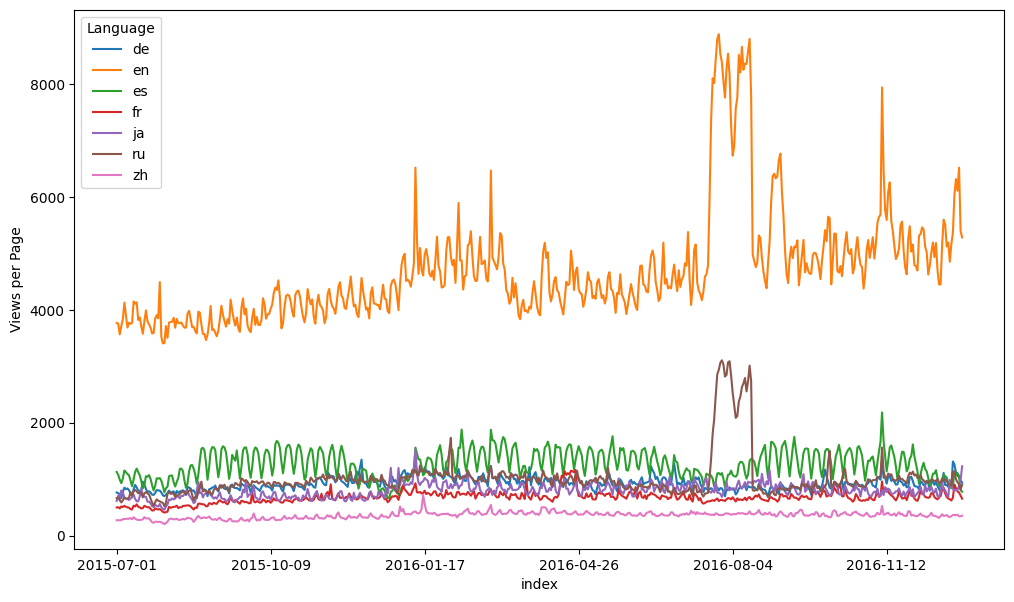

In [ ]:
df_lang.plot(figsize=(12,7))
plt.ylabel('Views per Page')

Language-Wise Insights from Page Views:

From the plot, it’s clear that English (en) is the most preferred language among users, with a significantly higher number of page views compared to other languages.

Interestingly, we can also observe distinct peaks in the data. One such peak appears around 2016-08-04, noticeable in both the English (en) and Russian (ru) language data. These sudden spikes suggest that specific events might have driven increased traffic on those dates.

To investigate this further, we'll dive into the exogenous data provided for the English language and explore how external factors might be influencing these patterns.

Now, let’s focus on understanding the view patterns for the English language ("en") in more detail.

In [ ]:
df_en = df_lang["en"].to_frame().reset_index()

# Rename columns
df_en.columns = ["date", "views"]

df_en.set_index('date', inplace=True)

df_en.head()

,views
date,
2015-07-01,3767.328604
2015-07-02,3755.158765
2015-07-03,3565.225696
2015-07-04,3711.782932
2015-07-05,3833.433025


<Axes: xlabel='date'>

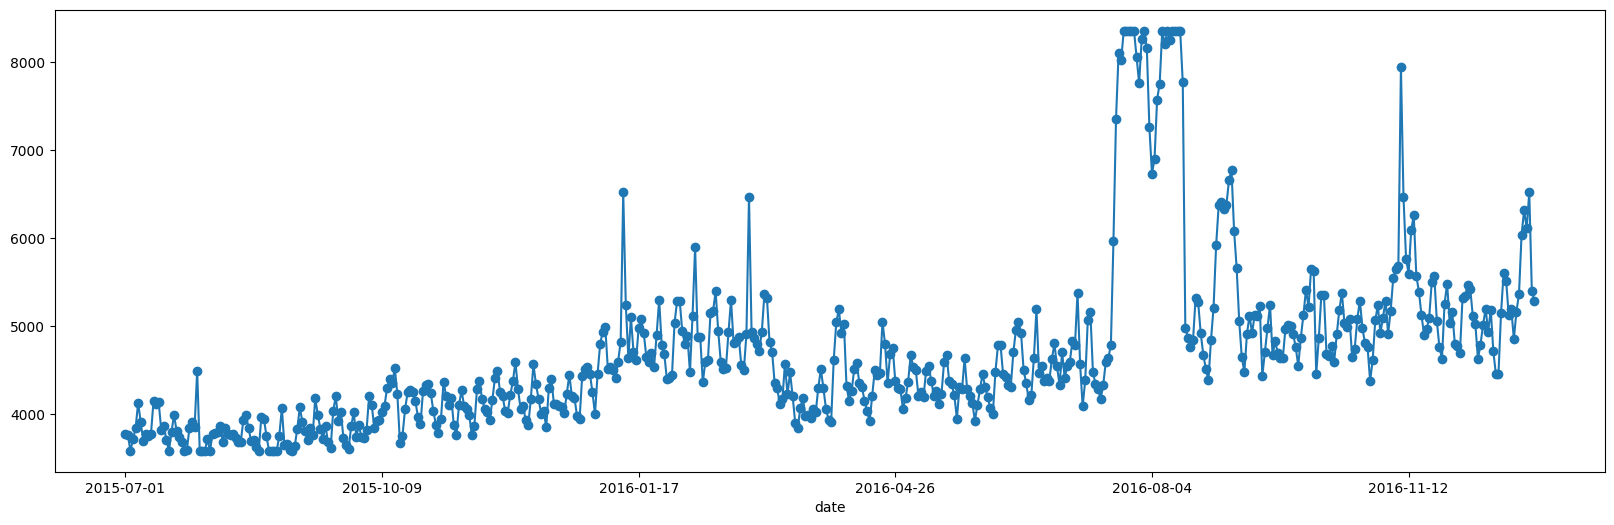

In [ ]:
# linear interpolation
df_en.views = df_en.views.interpolate(method='linear')

# anomalies - clip quantiles
df_en.views = df_en.views.clip(upper=df_en.views.quantile(0.98), lower=df_en.views.quantile(0.02))

# plot
df_en.views.plot(style='-o', figsize=(20,6))

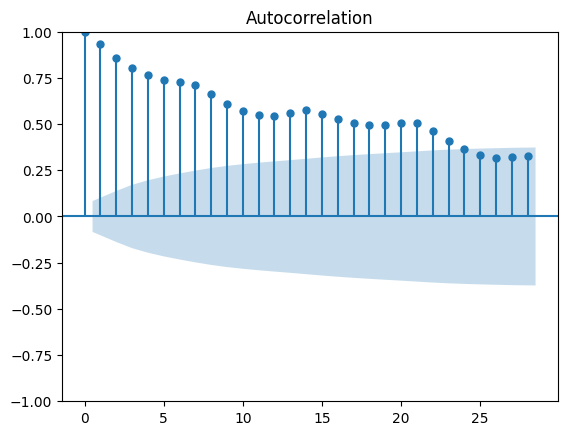

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_en.views);


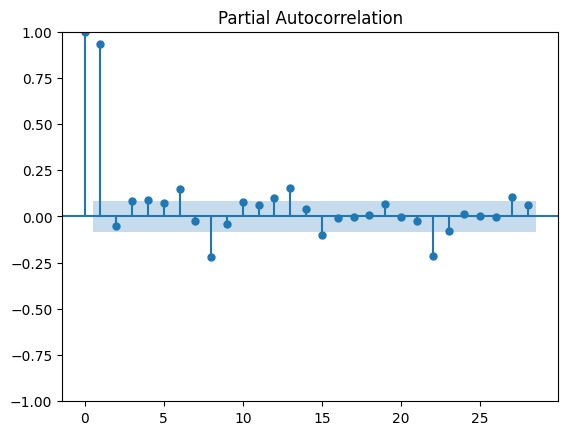

In [ ]:
plot_pacf(df_en.views);

Next check if our TS is stationary or not with the help of Dickey Fuller Test

In [ ]:
import statsmodels.api as sm
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(df_en.views)

Sequence is not stationary


In [ ]:
df_en_st = df_en.copy()
df_en_st.views = df_en_st.views.diff(1)
df_en_st.dropna(inplace=True)
adf_test(df_en_st.views)


Sequence is stationary


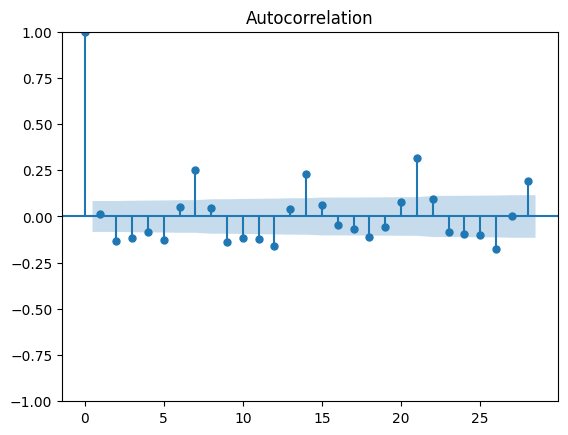

In [ ]:
plot_acf(df_en_st.views);

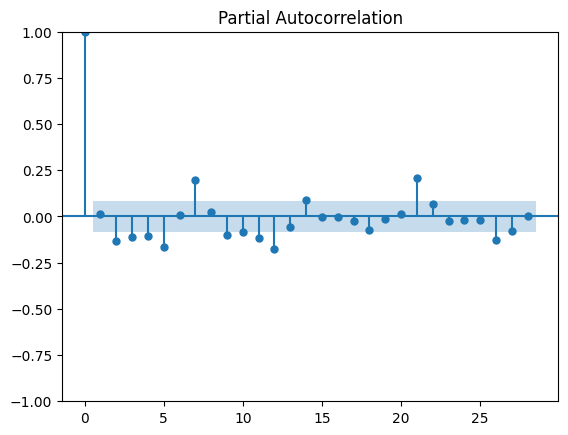

In [ ]:
plot_pacf(df_en_st.views);


ARIMA

In [ ]:
train=df_en[:520]
test=df_en[520:]

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit model (assume order=(p,d,q) from plots)
model = ARIMA(train['views'], order=(1,1,2))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))


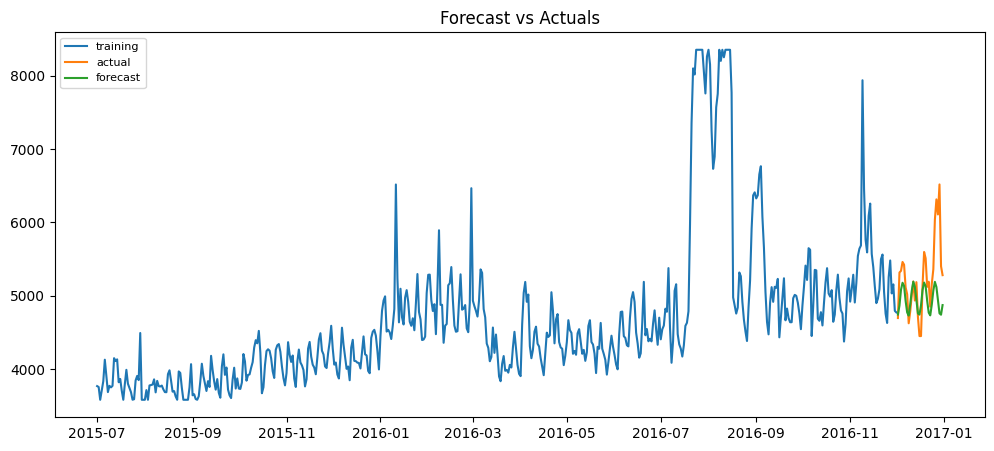

In [ ]:
import statsmodels.api as sm
train=df_en[:520]
test=df_en[520:]
model=sm.tsa.statespace.SARIMAX(train,order=(4, 1, 3))
results=model.fit()

fc=results.forecast(30,dynamic=True)

# Make as pandas series
fc_series = pd.Series(fc)
# Plot
train.index=train.index.astype('datetime64[ns]')
test.index=test.index.astype('datetime64[ns]')
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')

plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)

In [ ]:
mape = np.mean(np.abs(fc - test.views)/np.abs(test.views))
rmse = np.mean((fc - test.views)**2)**.5
print("mape:",mape)
print("rsme:",rmse)

mape: 0.06798136076869131
rsme: 542.7231365227891


In [ ]:
#Using exog in SARIMAX
ex=Exog_Campaign['Exog'].to_numpy()


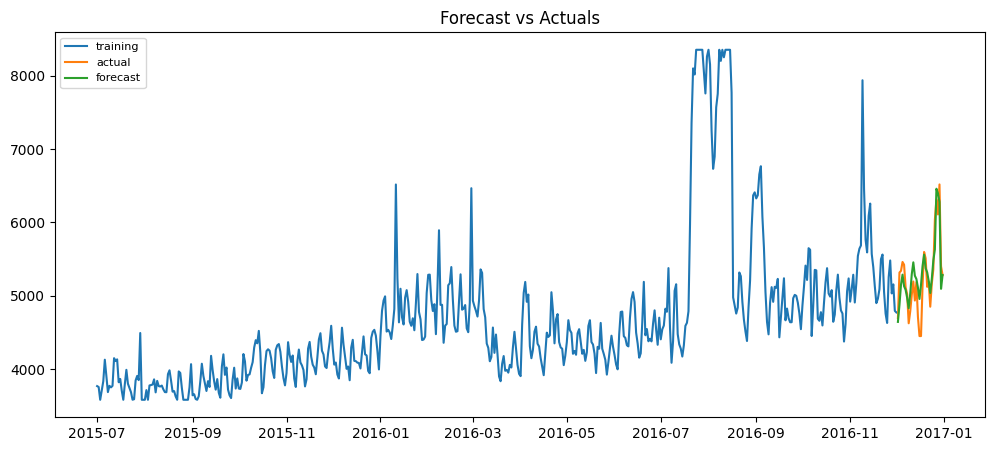

In [ ]:
train=df_en[:520]
test=df_en[520:]
model=sm.tsa.statespace.SARIMAX(train,order=(4, 1, 3),seasonal_order=(1,1,1,7),exog=ex[:520])
results=model.fit()

fc=results.forecast(30,dynamic=True,exog=pd.DataFrame(ex[520:]))

# Make as pandas series
fc_series = pd.Series(fc)
# Plot
train.index=train.index.astype('datetime64[ns]')
test.index=test.index.astype('datetime64[ns]')
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')

plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)

In [ ]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

In [ ]:
mape = np.mean(np.abs(fc - test.views)/np.abs(test.views))
rmse = np.mean((fc - test.views)**2)**.5
print("mape:",mape)
print("rsme:",rmse)

mape: 0.04316981881816547
rsme: 272.49419648662285


FB Prophet

In [ ]:
df_en

,views
date,
2015-07-01,3767.328604
2015-07-02,3755.158765
2015-07-03,3580.822233
2015-07-04,3711.782932
2015-07-05,3833.433025
...,...
2016-12-27,6314.335275
2016-12-28,6108.874144
2016-12-29,6518.058525


In [ ]:
Exog_Campaign

,Exog
0,0
1,0
2,0
3,0
4,0
...,...
545,1
546,1
547,1
548,0


In [ ]:
pip install prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpymb993wp/4xp407lf.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpymb993wp/mxvsiigo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24191', 'data', 'file=/tmp/tmpymb993wp/4xp407lf.json', 'init=/tmp/tmpymb993wp/mxvsiigo.json', 'output', 'file=/tmp/tmpymb993wp/prophet_modellkts1qe3/prophet_model-20250420145906.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:59:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:59:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


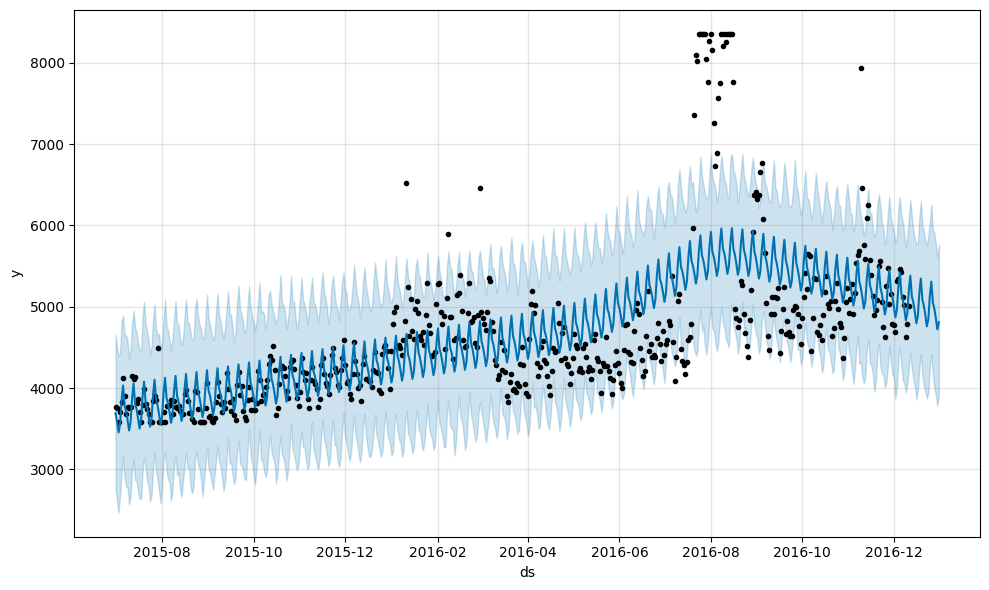

In [ ]:
from prophet import Prophet
m = Prophet(weekly_seasonality=True)

# Make sure your dataframe is named correctly and has 'ds' and 'y' columns
df_en.reset_index(inplace=True)  # Reset index to get 'date' column
df_en.rename(columns={'date': 'ds', 'views': 'y'}, inplace=True)  # Rename to 'ds' and 'y'

m.fit(df_en[['ds', 'y']][:-20])  # Use df_en instead of df2
future = m.make_future_dataframe(periods=20, freq="D")
forecast = m.predict(future)
fig = m.plot(forecast)

In [ ]:
exog_train = Exog_Campaign[:520]
exog_test = Exog_Campaign[520:]
#

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Assuming 'Exog_Campaign' has a 'date' column corresponding to 'train' index
exog_train = Exog_Campaign[:520].set_index(train.index)  # Align exog_train index
exog_test = Exog_Campaign[520:].set_index(test.index)    # Align exog_test index


model = SARIMAX(train['views'], exog=exog_train, order=(1,1,1), seasonal_order=(1,1,1,7))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test), exog=exog_test)

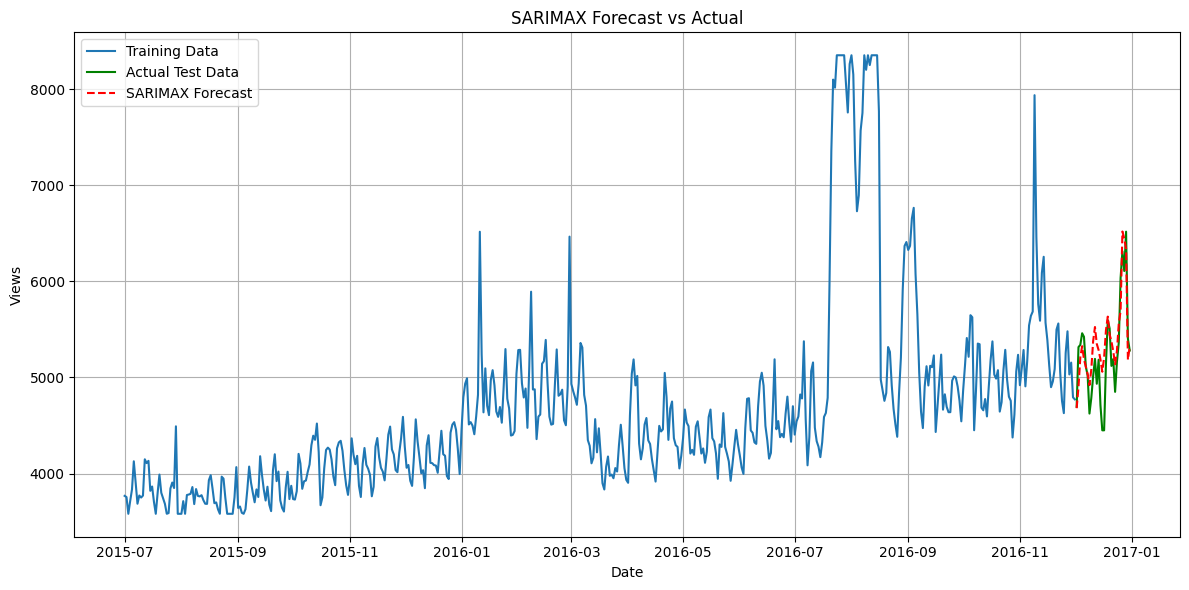

In [ ]:
import matplotlib.pyplot as plt

# Plotting actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['views'], label='Training Data')
plt.plot(test.index, test['views'], label='Actual Test Data', color='green')
plt.plot(test.index, forecast, label='SARIMAX Forecast', color='red', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Views')
plt.title('SARIMAX Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))


In [ ]:
mape = np.mean(np.abs(fc - test.views)/np.abs(test.views))
rmse = np.mean((fc - test.views)**2)**.5
print("mape:",mape)
print("rsme:",rmse)


mape: 0.04316981881816547
rsme: 272.49419648662285


FB Prophet

In [ ]:
df2=df_en.copy()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpymb993wp/io_cxcai.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpymb993wp/4lafda3b.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67769', 'data', 'file=/tmp/tmpymb993wp/io_cxcai.json', 'init=/tmp/tmpymb993wp/4lafda3b.json', 'output', 'file=/tmp/tmpymb993wp/prophet_modelxyae2x3i/prophet_model-20250420150541.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:05:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:05:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


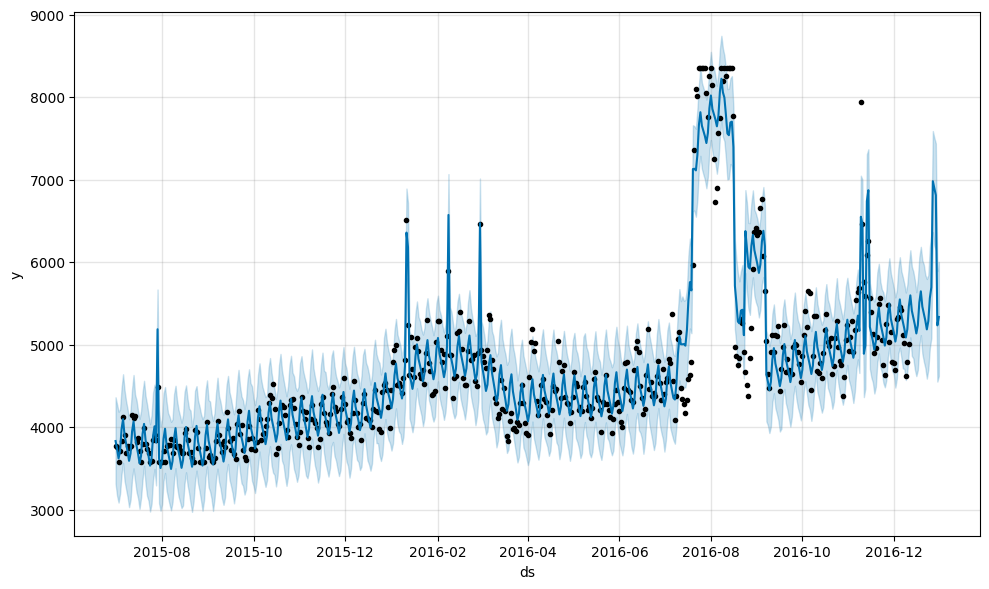

In [ ]:
df2=df_en.copy()
df2.reset_index(inplace=True)
df2.rename(columns={'date': 'ds', 'views': 'y'}, inplace=True)

# Assuming Exog_Campaign has the same length as df2
# and you want to use the 'Exog' column as the regressor:
df2['exog'] = Exog_Campaign['Exog'].values  # Add the 'exog' column

model2=Prophet(interval_width=0.9, weekly_seasonality=True, changepoint_prior_scale=1)
model2.add_regressor('exog')
model2.fit(df2[:-20])  # Now df2 has the 'exog' column
forecast2 = model2.predict(df2)
fig = model2.plot(forecast2)

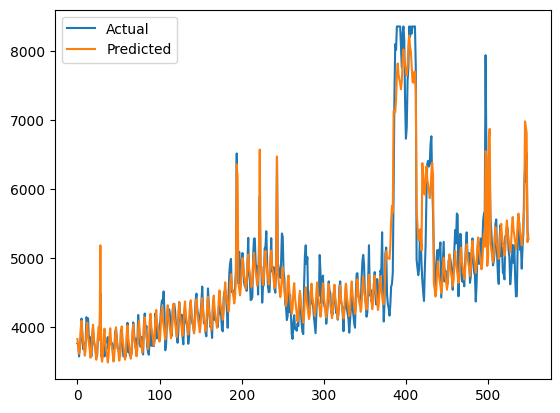

In [ ]:
y_true = df2['y'].values
y_pred = forecast2['yhat'].values

plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

In [ ]:
mape = np.mean(np.abs(forecast2['yhat'][-20:] - df2['y'][-20:].values)/np.abs(df2['y'][-20:].values))
print("mape:",mape)


mape: 0.06568044639394752


Conclusion

The SARIMAX model outperformed both ARIMA and Facebook Prophet in terms of forecasting accuracy.

The data clearly exhibits both seasonality and trend, making seasonal models more appropriate.

A differencing of order 1 was necessary to achieve stationarity.

The optimal values for (p, d, q) and (P, D, Q, s) were determined through multiple iterations and evaluation of ACF and PACF plots.

Recommendations Based on MAPE and Mean Visits

English:
English pages show the highest average visits and the lowest MAPE, making them the most effective platform for advertisements. Priority should be given to advertising on English-language pages.


Questionnaire:

1. Defining the problem statements and where can this and modifications of this
be used?

We're part of the Data Science team at AdEase, and our goal is to analyze page view data from over 145,000 Wikipedia pages across 550 days. By forecasting daily views, we aim to help clients make smarter decisions about ad placements in different regions and languages. With accurate predictions of when traffic spikes will occur, businesses can time their ads better—reaching more people while spending less. This not only improves ad efficiency but also helps optimize the overall marketing strategy.

2. Write 3 inferences you made from the data visualizations

3 Key Inferences from the Visualizations:

Language Distribution:

English has the highest number of Wikipedia pages, followed by Japanese, German, and French. These four languages dominate the content volume.

Access Insights:

Most users access Wikipedia via All-access (51.4%), followed by mobile-web (24.9%) and desktop (23.6%). In terms of origin, all-agents make up 75.8% of visits, while spiders (bots) account for 24.2%.

Performance by Language:

English performs the best—highest traffic and lowest error (MAPE), making it the top choice for ad campaigns.

Chinese has the least traffic, so unless there's a targeted need, it may not be worth advertising here.

Russian shows promise—moderate traffic with low MAPE.

Spanish has high visits but also high MAPE, which may reduce ad effectiveness.

French, German, and Japanese have average performance and can be considered based on campaign goals.

3. What does time series decomposition do?

Decomposition breaks a time series into key components: Trend, Seasonality, and Residual (noise). It helps us understand patterns over time.
We used an Additive model for this project, which assumes the components add up (rather than multiply) to form the full series.

4. What level of differencing made the series stationary?

We applied first-order differencing to remove trend and make the series stationary. This means we subtracted each value from the one before it. In some cases, if the series remained non-stationary, we considered seasonal differencing, especially for weekly patterns (e.g., 7-day cycles). Once the series stopped showing trends, we didn’t need to difference it further.

5. Difference between ARIMA, SARIMA, and SARIMAX:

ARIMA handles non-seasonal time series and focuses on three parameters:

p (autoregression), d (differencing), q (moving average).
It's suitable for data without clear seasonality.

SARIMA adds seasonal components to ARIMA, using:

(P, D, Q, s) for seasonal patterns, where s is the seasonal cycle (e.g., 7 for weekly).
Ideal for series with repeating seasonal trends.

SARIMAX is SARIMA with exogenous variables, meaning it incorporates external factors (like ad campaigns, holidays, weather) to improve forecasting accuracy.

6. Compare the number of views in different languages

View Comparison Across Languages:

Average (mean) visits by language (in order of popularity):
English > Spanish > Russian > German > Japanese > French > Chinese

7. What other methods other than grid search would be suitable to get the model for all languages?

Alternative to Grid Search for Model Tuning:
Besides grid search, we can tune model parameters using:

Domain Knowledge:
Prior experience or understanding of user behavior in different regions can guide parameter selection without brute force search.

ACF & PACF Plots:
These statistical plots help estimate:

p (from PACF): based on where the plot first cuts off.

q (from ACF): based on the lag where the autocorrelation dies off.

Stationarity Testing:
Using the Augmented Dickey-Fuller (ADF) test to determine if differencing is needed. Based on results, we decide the value of d (order of differencing).